In [ ]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the training dataset
df_train = pd.read_csv('/content/drive/MyDrive/UjiKomputasi/Data Train Saudi Employee Attrition.csv')

# Rename the previously loaded 'df' (which was the test dataset) to df_test for clarity
df_test = df.copy()

print("Dataset 'df_train' (training data) loaded successfully. Shape:", df_train.shape)
print("Dataset 'df_test' (test data) renamed and available. Shape:", df_test.shape)

Dataset 'df_train' (training data) loaded successfully. Shape: (1219, 34)
Dataset 'df_test' (test data) renamed and available. Shape: (235, 34)


# EDA

In [ ]:
# Display the first 5 rows of df_train
print("\nFirst 5 rows of df_train:")
display(df_train.head())

# Display the first 5 rows of df_test
print("\nFirst 5 rows of df_test:")
display(df_test.head())


First 5 rows of df_train:


,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,JobTitle,MonthlySalary,...,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities,Attrition
0,0.0,1.0,0.447209,0.0,0.0,0.0,0.565187,0.600378,0.623277,0.0,...,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1
1,0.0,0.0,0.405953,1.0,0.0,0.0,0.565187,0.555349,0.203456,1.0,...,2.0,2.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0
2,1.0,0.0,0.447209,1.0,0.0,0.0,0.456738,0.556474,0.294946,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0
3,1.0,1.0,0.447209,1.0,1.0,0.0,0.512493,0.556474,0.686866,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1
4,0.0,0.0,0.447209,0.0,0.0,0.0,0.260830,0.368713,0.329003,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0



First 5 rows of df_test:


,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,JobTitle,MonthlySalary,...,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities,Attrition
0,1,1,0.447209,1,1,1,0.565187,0.464505,0.178024,2,...,1,1,0,1,1,0,2,2,0,0
1,0,2,0.405953,1,2,2,0.260830,0.229320,0.190450,2,...,1,1,2,0,1,1,1,1,0,1
2,1,1,0.405953,1,2,2,0.456738,0.556474,0.602688,2,...,2,1,1,2,1,0,2,2,1,0
3,1,0,0.447209,0,0,0,0.512493,0.555349,0.329003,0,...,0,1,1,1,0,0,1,1,0,0
4,1,1,0.405953,2,1,1,0.359278,0.263179,0.213082,1,...,1,1,0,0,1,0,2,2,0,0


In [ ]:
# Display general information about df_train
print("\nInformation about df_train:")
df_train.info()

# Display general information about df_test
print("\nInformation about df_test:")
df_test.info()


Information about df_train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Gender                                     1184 non-null   float64
 1   Age                                        1183 non-null   float64
 2   Maritalstatus                              1177 non-null   float64
 3   Academic_degree                            1173 non-null   float64
 4   Years_Experience                           1173 non-null   float64
 5   Years_experience_lastorganization          1176 non-null   float64
 6   Sector                                     1188 non-null   float64
 7   Department                                 1179 non-null   float64
 8   JobTitle                                   1177 non-null   float64
 9   MonthlySalary                              1184 non-null   float64


In [93]:
display(df_train.shape)
display(df_test.shape)

(1219, 34)

(235, 34)

In [ ]:
# Descriptive statistics for df_train
print("\nDescriptive statistics for df_train:")
display(df_train.describe())

# Descriptive statistics for df_test
print("\nDescriptive statistics for df_test:")
display(df_test.describe())


Descriptive statistics for df_train:


,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,JobTitle,MonthlySalary,...,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities,Attrition
count,1184.000000,1183.000000,1177.000000,1173.000000,1173.000000,1176.000000,1188.000000,1179.000000,1177.000000,1184.000000,...,1179.000000,1181.000000,1186.000000,1176.000000,1182.000000,1182.000000,1167.000000,1181.000000,1184.000000,1219.000000
mean,0.440034,0.780442,0.424139,0.942029,0.897939,0.654740,0.427851,0.426083,0.425422,0.987967,...,1.009882,0.988146,1.028668,1.059524,0.478849,0.158206,1.064267,0.939035,0.473818,0.418376
std,0.496601,1.002290,0.021561,0.653200,1.025483,0.958325,0.118565,0.130825,0.199847,1.192171,...,0.982779,0.633683,0.782199,0.803097,0.499764,0.365089,0.645727,0.678739,0.499525,0.493495
min,0.000000,0.000000,0.405953,0.000000,0.000000,0.000000,0.260830,0.229320,0.060599,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.405953,1.000000,0.000000,0.000000,0.359278,0.263179,0.230078,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.405953,1.000000,1.000000,0.000000,0.456738,0.464505,0.383548,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,0.447209,1.000000,1.000000,1.000000,0.565187,0.556474,0.623277,1.000000,...,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,5.468984,0.477853,3.000000,5.558624,5.356682,0.565187,0.600378,0.968011,7.102741,...,5.350919,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000



Descriptive statistics for df_test:


,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,JobTitle,MonthlySalary,...,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities,Attrition
count,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,...,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,0.395745,0.617021,0.424381,1.025532,0.702128,0.540426,0.418798,0.422197,0.416899,0.842553,...,0.821277,0.957447,0.965957,0.940426,0.476596,0.187234,1.153191,0.995745,0.510638,0.425532
std,0.490054,0.638949,0.021451,0.659729,0.719535,0.705188,0.116016,0.129885,0.191103,0.850275,...,0.693356,0.590431,0.805238,0.803746,0.500518,0.390932,0.655304,0.663440,0.500954,0.495479
min,0.000000,0.000000,0.405953,0.000000,0.000000,0.000000,0.260830,0.229320,0.118683,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.405953,1.000000,0.000000,0.000000,0.359278,0.263179,0.230078,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,0.405953,1.000000,1.000000,0.000000,0.359278,0.464505,0.368683,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,1.000000,1.000000,0.447209,1.000000,1.000000,1.000000,0.565187,0.555349,0.623277,1.000000,...,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000,2.000000,1.000000,1.000000,1.000000
max,1.000000,2.000000,0.477853,3.000000,2.000000,2.000000,0.565187,0.600378,0.968011,3.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000


Missing values in df_train:
Gender                                       35
Age                                          36
Maritalstatus                                42
Academic_degree                              46
Years_Experience                             46
Years_experience_lastorganization            43
Sector                                       31
Department                                   40
JobTitle                                     42
MonthlySalary                                35
Allowances                                   30
MedicalInsurance                             36
Bonus                                        39
OverTime                                     41
Payment_Overtime                             36
Rewards_Wages_Satisfaction                   27
Get_Deserved_Promotion                       31
Training_programs_During_last_three_years    43
Useful_Training_Programs                     35
Business_Travel                              30
Job_Support 

/tmp/ipython-input-1626363585.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df_train.index, y='Missing Percent', data=missing_df_train, palette='viridis')


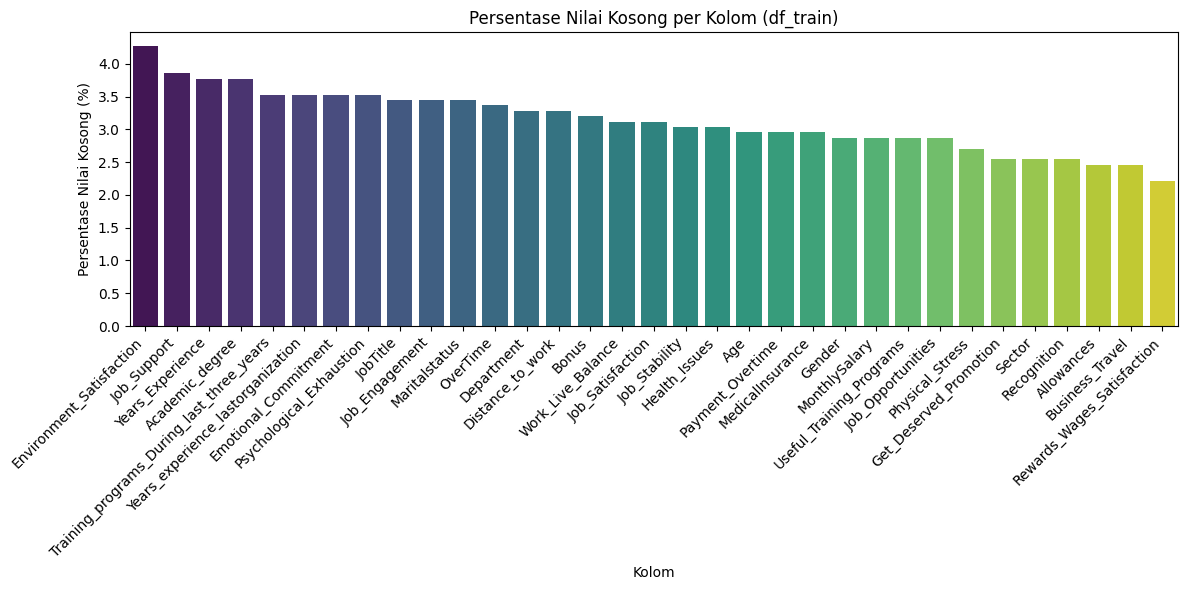


Missing values in df_test:
Gender                                       0
Age                                          0
Maritalstatus                                0
Academic_degree                              0
Years_Experience                             0
Years_experience_lastorganization            0
Sector                                       0
Department                                   0
JobTitle                                     0
MonthlySalary                                0
Allowances                                   0
MedicalInsurance                             0
Bonus                                        0
OverTime                                     0
Payment_Overtime                             0
Rewards_Wages_Satisfaction                   0
Get_Deserved_Promotion                       0
Training_programs_During_last_three_years    0
Useful_Training_Programs                     0
Business_Travel                              0
Job_Support                     

In [71]:
# Cek missing value di df_train
print("Missing values in df_train:")
print(df_train.isnull().sum())

# Hitung persentase nilai kosong untuk df_train
missing_values_train = df_train.isnull().sum()
missing_percent_train = 100 * missing_values_train / len(df_train)
missing_df_train = pd.DataFrame({'Missing Count': missing_values_train, 'Missing Percent': missing_percent_train})
missing_df_train = missing_df_train[missing_df_train['Missing Count'] > 0].sort_values(by='Missing Percent', ascending=False)

if not missing_df_train.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df_train.index, y='Missing Percent', data=missing_df_train, palette='viridis')
    plt.title('Persentase Nilai Kosong per Kolom (df_train)')
    plt.xlabel('Kolom')
    plt.ylabel('Persentase Nilai Kosong (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada nilai kosong di df_train.")

# Cek missing value di df_test
print("\nMissing values in df_test:")
print(df_test.isnull().sum())

# Hitung persentase nilai kosong untuk df_test
missing_values_test = df_test.isnull().sum()
missing_percent_test = 100 * missing_values_test / len(df_test)
missing_df_test = pd.DataFrame({'Missing Count': missing_values_test, 'Missing Percent': missing_percent_test})
missing_df_test = missing_df_test[missing_df_test['Missing Count'] > 0].sort_values(by='Missing Percent', ascending=False)

if not missing_df_test.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df_test.index, y='Missing Percent', data=missing_df_test, palette='magma')
    plt.title('Persentase Nilai Kosong per Kolom (df_test)')
    plt.xlabel('Kolom')
    plt.ylabel('Persentase Nilai Kosong (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada nilai kosong di df_test.")

Distribusi Attrition di df_train:
Attrition
0    709
1    510
Name: count, dtype: int64

Distribusi Attrition di df_test:
Attrition
0    135
1    100
Name: count, dtype: int64


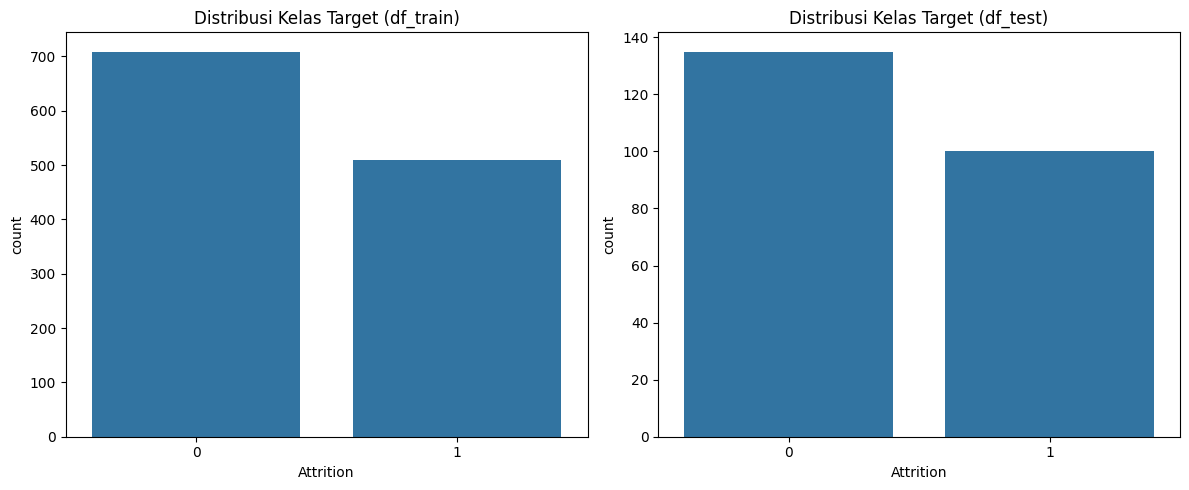

In [ ]:
# Visualisasi persebaran kelas target untuk df_train dan df_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
print("Distribusi Attrition di df_train:")
print(df_train['Attrition'].value_counts())
sns.countplot(x='Attrition', data=df_train)
plt.title('Distribusi Kelas Target (df_train)')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
print("\nDistribusi Attrition di df_test:")
print(df_test['Attrition'].value_counts())
sns.countplot(x='Attrition', data=df_test)
plt.title('Distribusi Kelas Target (df_test)')

plt.tight_layout()
plt.show()

In [ ]:
print("Duplicated rows in df_train:", df_train.duplicated().sum())
print("Duplicated rows in df_test:", df_test.duplicated().sum())

Duplicated rows in df_train: 85
Duplicated rows in df_test: 0



Boxplots for df_train:


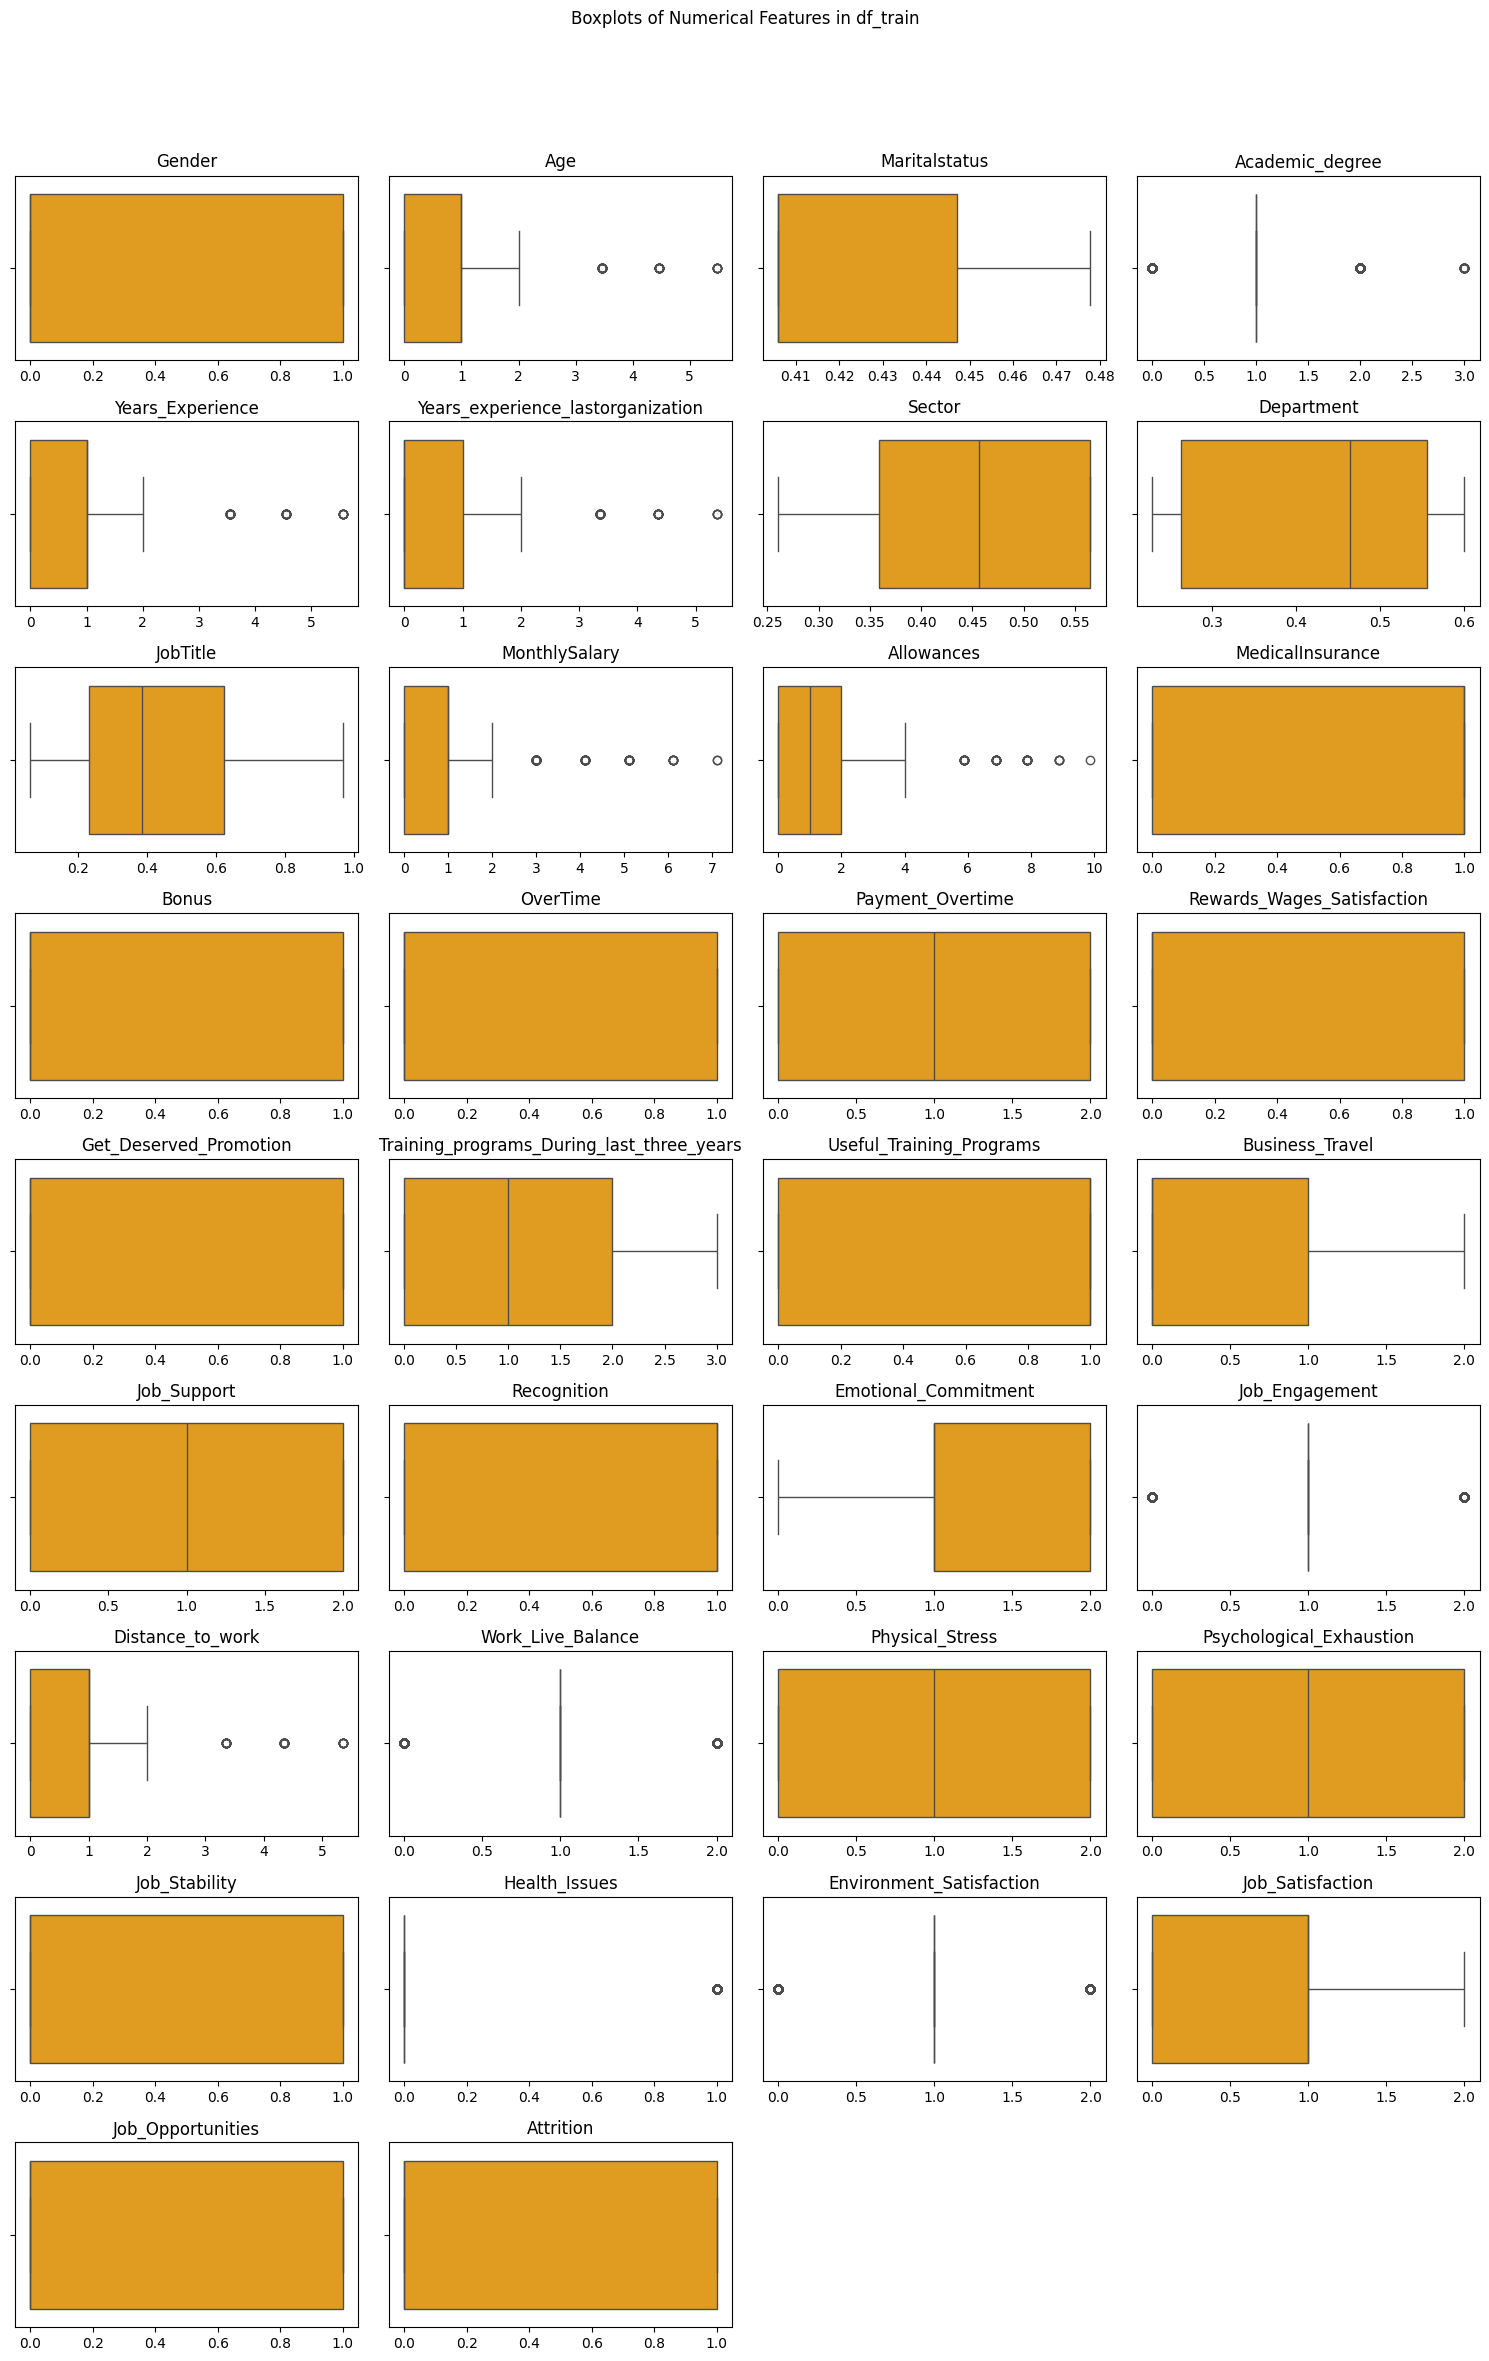


Boxplots for df_test:


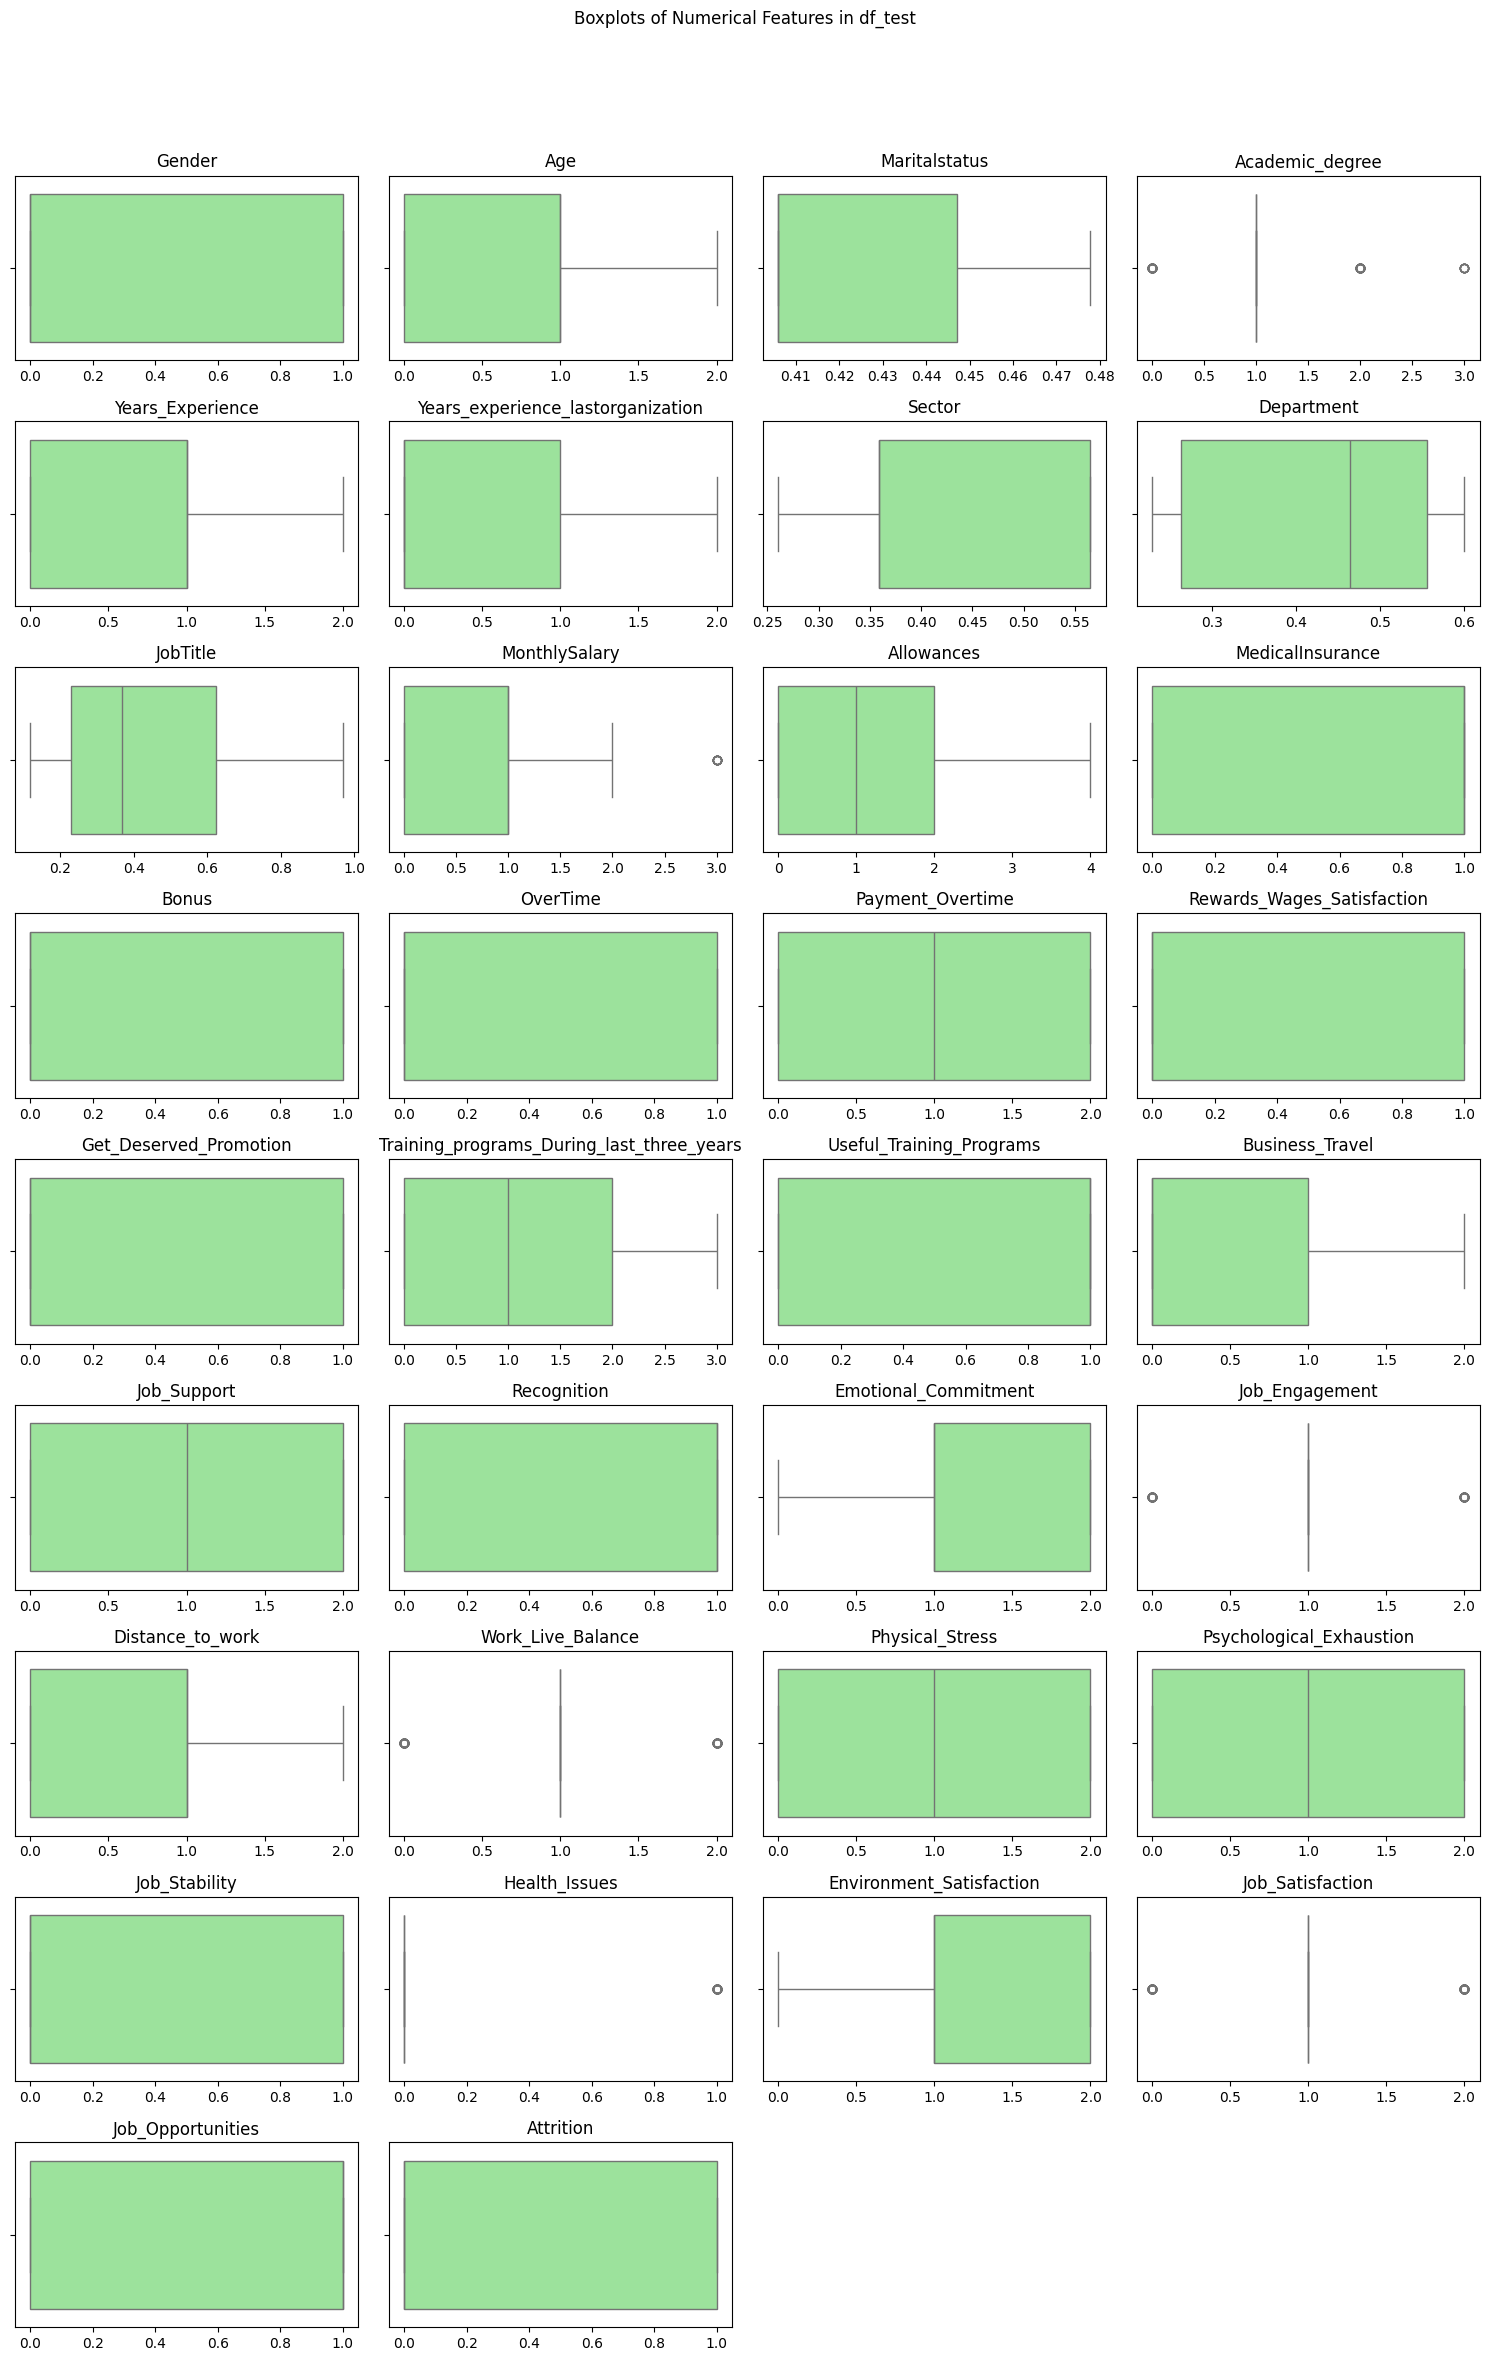

In [ ]:
# Identifikasi Outlier dan buat Boxplot untuk df_train
print("\nBoxplots for df_train:")
numerical_cols_train = df_train.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, len(numerical_cols_train) * 0.7))
plt.suptitle('Boxplots of Numerical Features in df_train', y=1.02)

for i, col in enumerate(numerical_cols_train):
    plt.subplot(len(numerical_cols_train) // 4 + 1, 4, i + 1) # Adjust subplot grid dynamically
    sns.boxplot(x=df_train[col], color='orange')
    plt.title(f'{col}')
    plt.xlabel('') # Remove x-label for cleaner look
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# Identifikasi Outlier dan buat Boxplot untuk df_test
print("\nBoxplots for df_test:")
numerical_cols_test = df_test.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, len(numerical_cols_test) * 0.7))
plt.suptitle('Boxplots of Numerical Features in df_test', y=1.02)

for i, col in enumerate(numerical_cols_test):
    plt.subplot(len(numerical_cols_test) // 4 + 1, 4, i + 1) # Adjust subplot grid dynamically
    sns.boxplot(x=df_test[col], color='lightgreen')
    plt.title(f'{col}')
    plt.xlabel('') # Remove x-label for cleaner look
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

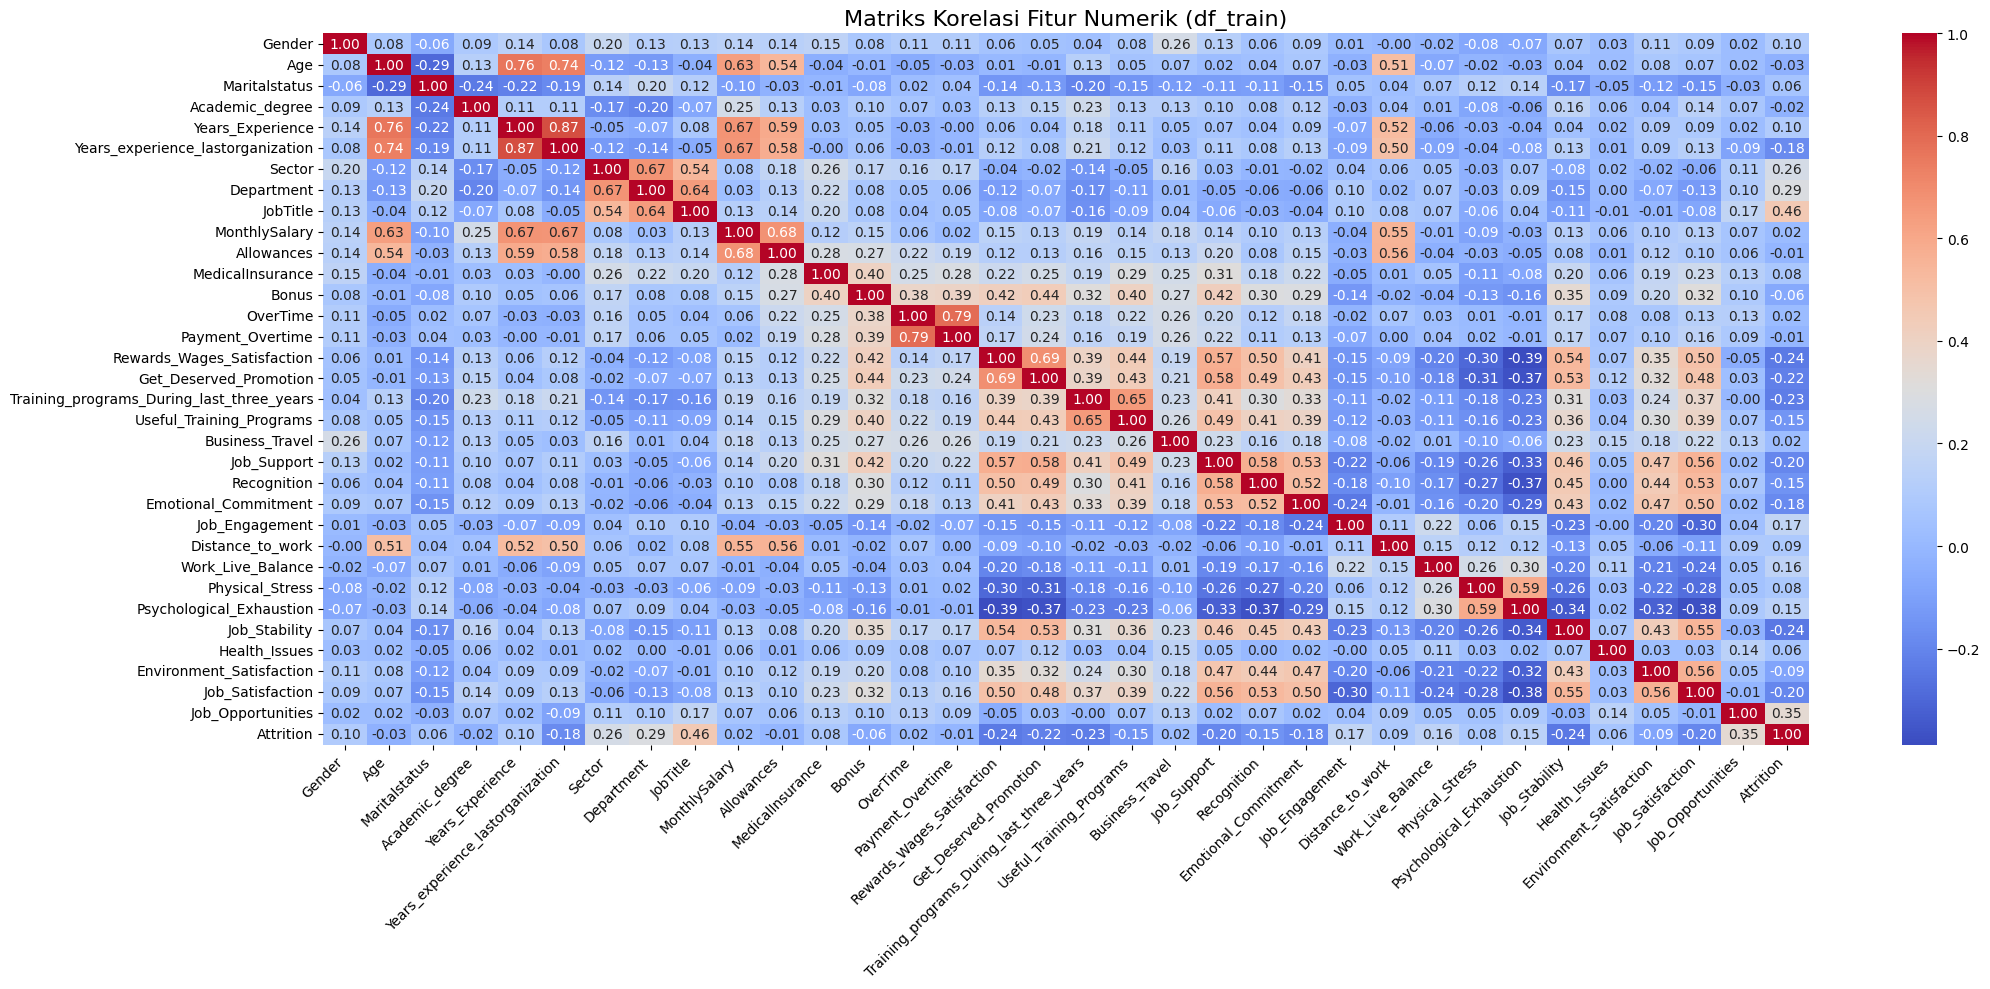

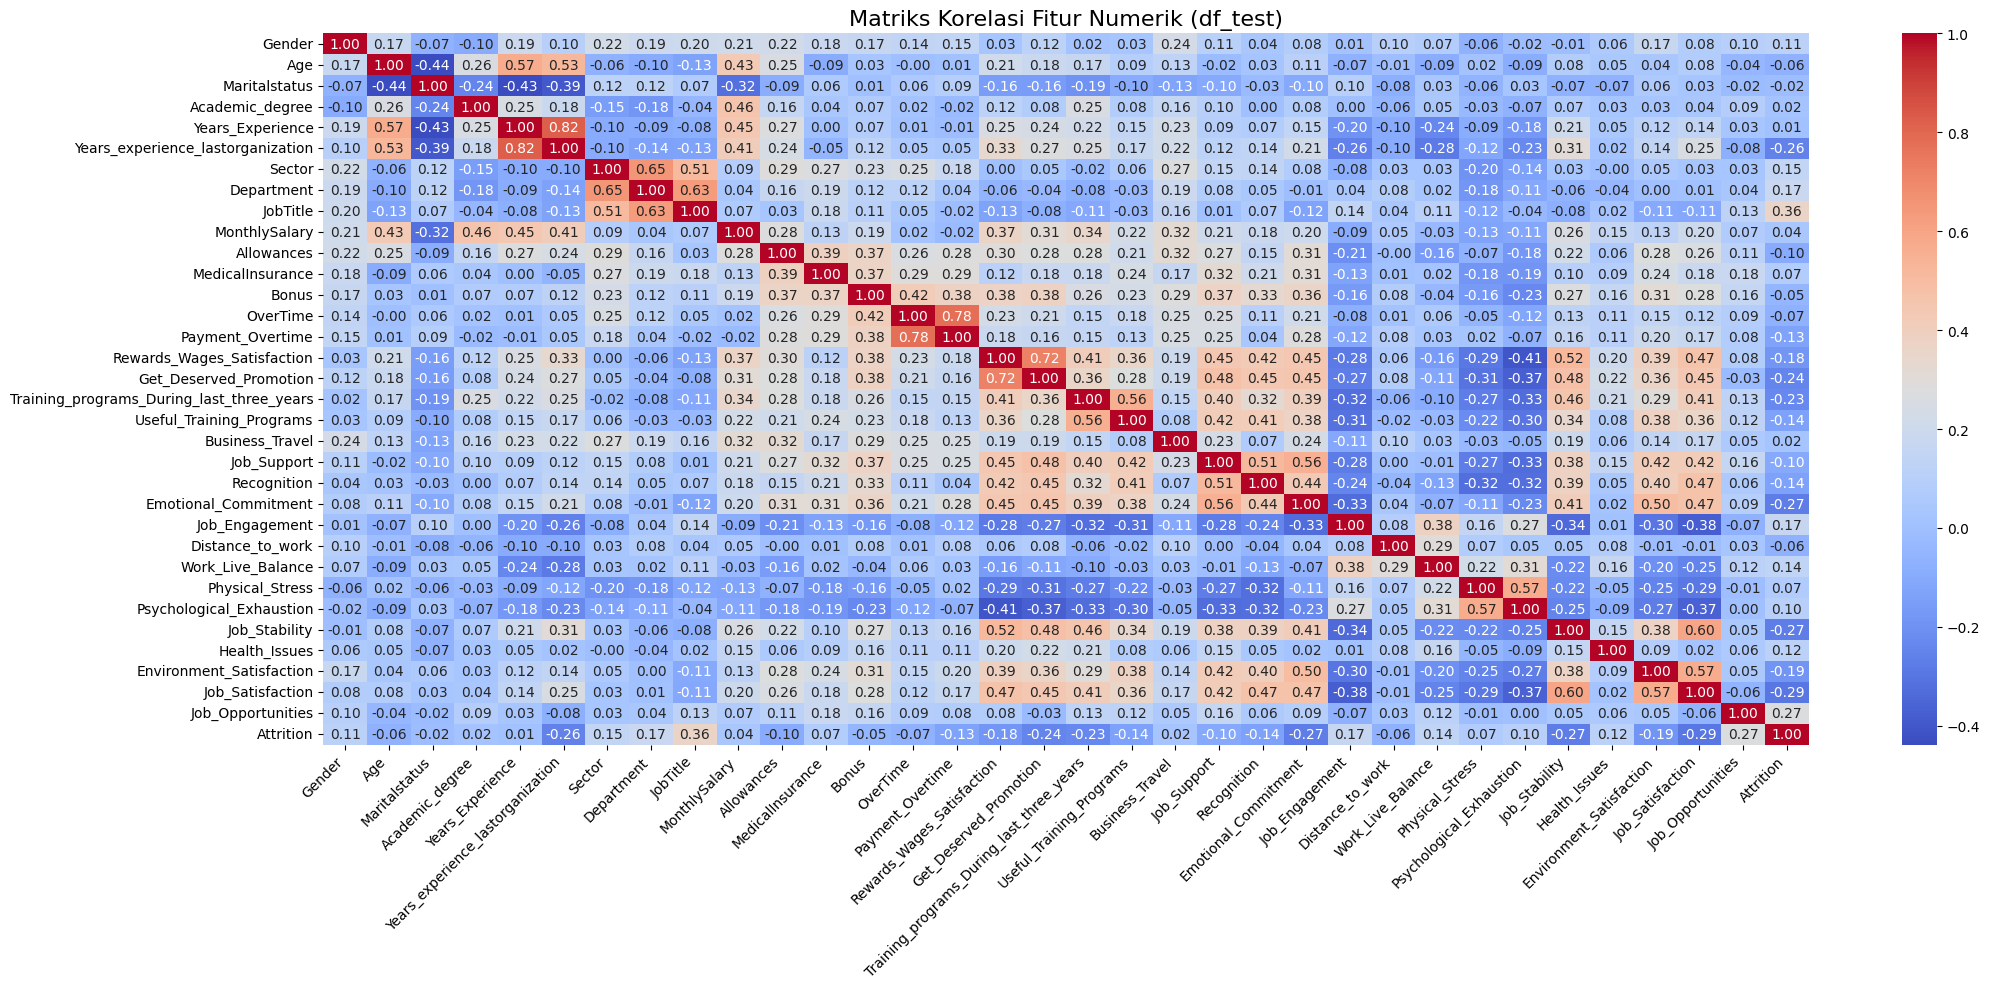

In [ ]:
# Korelasi antar fitur (Heatmap) untuk df_train
plt.figure(figsize=(22, 10))
df_processed_train = df_train.copy()
for col in df_processed_train.columns:
    if df_processed_train[col].dtype == 'object':
        df_processed_train[col] = df_processed_train[col].astype(str).str.strip().str.lower()
        if 'yes' in df_processed_train[col].unique() and 'no' in df_processed_train[col].unique():
            df_processed_train[col] = df_processed_train[col].map({'yes': 1, 'no': 0}).astype(float)
        else:
            try:
                df_processed_train[col] = pd.to_numeric(df_processed_train[col])
            except ValueError:
                df_processed_train = df_processed_train.drop(columns=[col])

df_numeric_train = df_processed_train.select_dtypes(include=['number'])

sns.heatmap(df_numeric_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik (df_train)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Korelasi antar fitur (Heatmap) untuk df_test
plt.figure(figsize=(22, 10))
df_processed_test = df_test.copy()
for col in df_processed_test.columns:
    if df_processed_test[col].dtype == 'object':
        df_processed_test[col] = df_processed_test[col].astype(str).str.strip().str.lower()
        if 'yes' in df_processed_test[col].unique() and 'no' in df_processed_test[col].unique():
            df_processed_test[col] = df_processed_test[col].map({'yes': 1, 'no': 0}).astype(float)
        else:
            try:
                df_processed_test[col] = pd.to_numeric(df_processed_test[col])
            except ValueError:
                df_processed_test = df_processed_test.drop(columns=[col])

df_numeric_test = df_processed_test.select_dtypes(include=['number'])

sns.heatmap(df_numeric_test.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik (df_test)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Pemodelan Awal Tanpa Preprocessing

In [ ]:
# Import library untuk modeling
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Pisahkan fitur (X) dan target (y) untuk dataset pelatihan dan pengujian
X_train = df_train.drop('Attrition', axis=1)
y_train = df_train['Attrition']

X_test = df_test.drop('Attrition', axis=1)
y_test = df_test['Attrition']

print("Persiapan data selesai. Memulai pelatihan model tanpa preprocessing...")

Persiapan data selesai. Memulai pelatihan model tanpa preprocessing...



--- Decision Tree Classifier ---
Laporan Klasifikasi untuk Decision Tree:
              precision    recall  f1-score   support

           0       0.73      0.78      0.76       135
           1       0.67      0.62      0.65       100

    accuracy                           0.71       235
   macro avg       0.70      0.70      0.70       235
weighted avg       0.71      0.71      0.71       235

Akurasi untuk Decision Tree: 0.7106382978723405
AUC-ROC untuk Decision Tree: 0.6988888888888889


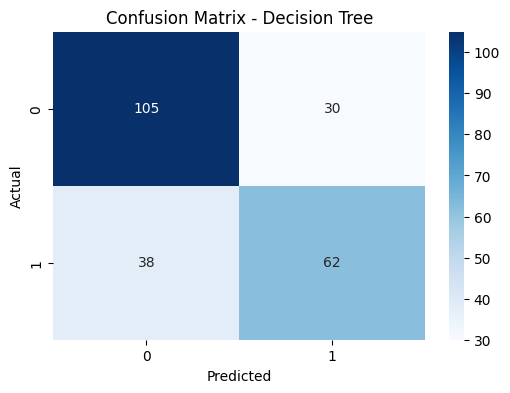


--- Random Forest Classifier ---
Laporan Klasifikasi untuk Random Forest:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       135
           1       0.76      0.65      0.70       100

    accuracy                           0.76       235
   macro avg       0.76      0.75      0.75       235
weighted avg       0.76      0.76      0.76       235

Akurasi untuk Random Forest: 0.7617021276595745
AUC-ROC untuk Random Forest: 0.8535925925925926


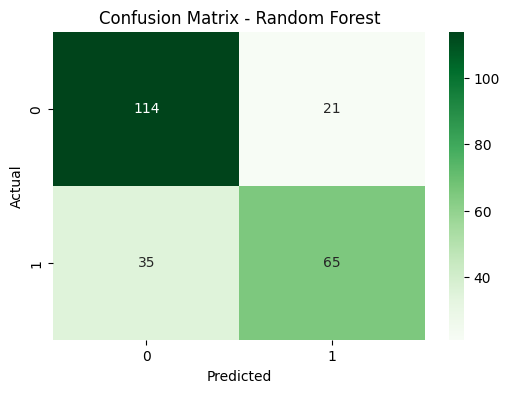


--- XGBoost Classifier ---
Laporan Klasifikasi untuk XGBoost:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       135
           1       0.83      0.71      0.76       100

    accuracy                           0.81       235
   macro avg       0.82      0.80      0.80       235
weighted avg       0.81      0.81      0.81       235

Akurasi untuk XGBoost: 0.8127659574468085
AUC-ROC untuk XGBoost: 0.8914074074074074


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:12:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


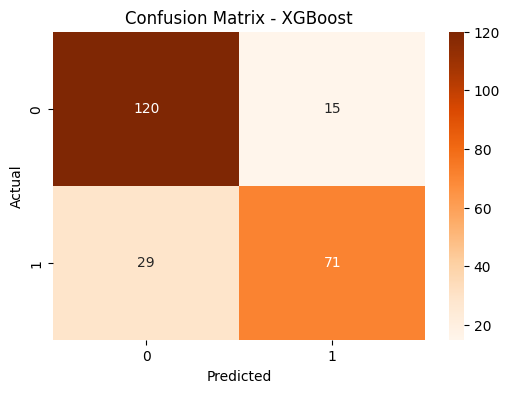

In [ ]:
# Import necessary library for AUC-ROC
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# 1. Decision Tree Classifier
print("\n--- Decision Tree Classifier ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
print("Laporan Klasifikasi untuk Decision Tree:")
print(classification_report(y_test, y_pred_dt))
print("Akurasi untuk Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("AUC-ROC untuk Decision Tree:", roc_auc_score(y_test, y_proba_dt))

# Visualisasi Confusion Matrix untuk Decision Tree
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. Random Forest Classifier
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("Laporan Klasifikasi untuk Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("Akurasi untuk Random Forest:", accuracy_score(y_test, y_pred_rf))
print("AUC-ROC untuk Random Forest:", roc_auc_score(y_test, y_proba_rf))

# Visualisasi Confusion Matrix untuk Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. XGBoost Classifier
print("\n--- XGBoost Classifier ---")
# Untuk XGBoost, 'use_label_encoder=False' dan 'eval_metric' diatur untuk menekan peringatan
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("Laporan Klasifikasi untuk XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("Akurasi untuk XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("AUC-ROC untuk XGBoost:", roc_auc_score(y_test, y_proba_xgb))

# Visualisasi Confusion Matrix untuk XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Preprocessing

In [94]:
# Menangani Missing Values di df_train

# Identifikasi kolom numerik dengan missing values di df_train
numerical_cols_with_missing = df_train.select_dtypes(include=np.number).columns[df_train.select_dtypes(include=np.number).isnull().any()].tolist()

print("Kolom numerik dengan missing values di df_train:", numerical_cols_with_missing)

# Mengisi missing values dengan median untuk kolom numerik di df_train
for col in numerical_cols_with_missing:
    median_value = df_train[col].median()
    df_train[col].fillna(median_value, inplace=True);

print("\nMissing values di df_train setelah imputasi:")
print(df_train.isnull().sum())

Kolom numerik dengan missing values di df_train: []

Missing values di df_train setelah imputasi:
Gender                                       0
Age                                          0
Maritalstatus                                0
Academic_degree                              0
Years_Experience                             0
Years_experience_lastorganization            0
Sector                                       0
Department                                   0
JobTitle                                     0
MonthlySalary                                0
Allowances                                   0
MedicalInsurance                             0
Bonus                                        0
OverTime                                     0
Payment_Overtime                             0
Rewards_Wages_Satisfaction                   0
Get_Deserved_Promotion                       0
Training_programs_During_last_three_years    0
Useful_Training_Programs                     0
Business_

In [ ]:
# Menangani Duplikat

# Menghapus baris duplikat dari df_train
print(f"Jumlah baris duplikat di df_train sebelum penghapusan: {df_train.duplicated().sum()}")
df_train.drop_duplicates(inplace=True)
print(f"Jumlah baris duplikat di df_train setelah penghapusan: {df_train.duplicated().sum()}")

# Memastikan tidak ada duplikat di df_test (sudah dicek sebelumnya dan hasilnya 0)
print(f"Jumlah baris duplikat di df_test: {df_test.duplicated().sum()}")

Jumlah baris duplikat di df_train sebelum penghapusan: 85
Jumlah baris duplikat di df_train setelah penghapusan: 0
Jumlah baris duplikat di df_test: 0


In [ ]:
# Penanganan Outlier (Domain-Driven Outlier Detection) untuk df_train

print("\n--- Penanganan Outlier untuk df_train ---")

numerical_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Exclude 'Attrition' from outlier detection as it's the target variable
if 'Attrition' in numerical_cols:
    numerical_cols.remove('Attrition')

# Membuat salinan df_train untuk penanganan outlier
df_train_cleaned = df_train.copy()

for col in numerical_cols:
    Q1 = df_train_cleaned[col].quantile(0.25)
    Q3 = df_train_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    # Batas atas dan bawah. Faktor 1.5 ini bisa disesuaikan dengan domain knowledge.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah outlier sebelum capping
    outliers_count = df_train_cleaned[(df_train_cleaned[col] < lower_bound) | (df_train_cleaned[col] > upper_bound)].shape[0]

    if outliers_count > 0:
        # Capping outliers: mengganti nilai di bawah lower_bound dengan lower_bound,
        # dan nilai di atas upper_bound dengan upper_bound.
        df_train_cleaned[col] = np.where(df_train_cleaned[col] < lower_bound, lower_bound, df_train_cleaned[col])
        df_train_cleaned[col] = np.where(df_train_cleaned[col] > upper_bound, upper_bound, df_train_cleaned[col])
        print(f"Kolom '{col}': {outliers_count} outlier ditangani dengan capping.")
    #else:
        #print(f"Kolom '{col}': Tidak ada outlier yang terdeteksi dengan metode IQR.")

print("\nPenanganan outlier selesai untuk df_train. DataFrame baru 'df_train_cleaned' telah dibuat.")
print("Shape df_train_cleaned setelah penanganan outlier:", df_train_cleaned.shape)

# Untuk df_test, kita biasanya menerapkan transformasi yang sama yang dipelajari dari df_train
# Namun, untuk demonstrasi, kita akan menyalinnya langsung untuk saat ini, atau bisa juga menerapkan capping jika diperlukan.
print("\n--- Penanganan Outlier untuk df_test ---")
df_test_cleaned = df_test.copy()
# Jika df_test juga memiliki outlier, langkah capping yang sama bisa diterapkan di sini.
print("Penanganan outlier di df_test akan menggunakan batas yang sama atau disesuaikan jika ada domain knowledge khusus.")
print("Shape df_test_cleaned:", df_test_cleaned.shape)


--- Penanganan Outlier untuk df_train ---
Kolom 'Age': 56 outlier ditangani dengan capping.
Kolom 'Academic_degree': 401 outlier ditangani dengan capping.
Kolom 'Years_Experience': 56 outlier ditangani dengan capping.
Kolom 'Years_experience_lastorganization': 56 outlier ditangani dengan capping.
Kolom 'MonthlySalary': 104 outlier ditangani dengan capping.
Kolom 'Allowances': 56 outlier ditangani dengan capping.
Kolom 'Job_Engagement': 417 outlier ditangani dengan capping.
Kolom 'Distance_to_work': 56 outlier ditangani dengan capping.
Kolom 'Work_Live_Balance': 446 outlier ditangani dengan capping.
Kolom 'Health_Issues': 168 outlier ditangani dengan capping.
Kolom 'Environment_Satisfaction': 461 outlier ditangani dengan capping.

Penanganan outlier selesai untuk df_train. DataFrame baru 'df_train_cleaned' telah dibuat.
Shape df_train_cleaned setelah penanganan outlier: (1134, 34)

--- Penanganan Outlier untuk df_test ---
Penanganan outlier di df_test akan menggunakan batas yang sama a

# Pemodelan Setelah Preprocessing

In [ ]:
# Pisahkan fitur (X) dan target (y) dari DataFrame yang sudah dibersihkan

X_train_preprocessed = df_train_cleaned.drop('Attrition', axis=1)
y_train_preprocessed = df_train_cleaned['Attrition']

X_test_preprocessed = df_test_cleaned.drop('Attrition', axis=1)
y_test_preprocessed = df_test_cleaned['Attrition']

print("Shape X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape y_train_preprocessed:", y_train_preprocessed.shape)
print("Shape X_test_preprocessed:", X_test_preprocessed.shape)
print("Shape y_test_preprocessed:", y_test_preprocessed.shape)

Shape X_train_preprocessed: (1134, 33)
Shape y_train_preprocessed: (1134,)
Shape X_test_preprocessed: (235, 33)
Shape y_test_preprocessed: (235,)


Memulai pelatihan model dengan data hasil preprocessing...

--- Decision Tree Classifier (Preprocessed Data) ---
Laporan Klasifikasi untuk Decision Tree (Preprocessed Data):
              precision    recall  f1-score   support

           0       0.73      0.81      0.76       135
           1       0.69      0.59      0.64       100

    accuracy                           0.71       235
   macro avg       0.71      0.70      0.70       235
weighted avg       0.71      0.71      0.71       235

Akurasi untuk Decision Tree (Preprocessed Data): 0.7148936170212766
AUC-ROC untuk Decision Tree (Preprocessed Data): 0.6987037037037036


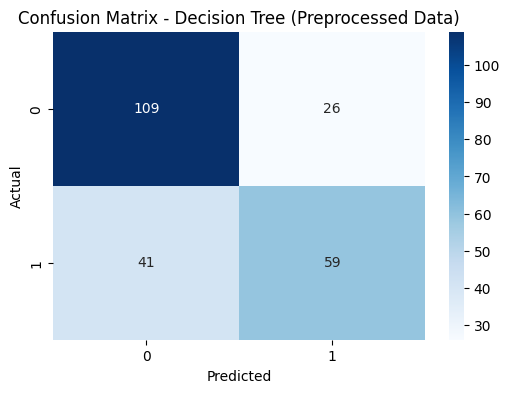


--- Random Forest Classifier (Preprocessed Data) ---
Laporan Klasifikasi untuk Random Forest (Preprocessed Data):
              precision    recall  f1-score   support

           0       0.75      0.87      0.80       135
           1       0.77      0.61      0.68       100

    accuracy                           0.76       235
   macro avg       0.76      0.74      0.74       235
weighted avg       0.76      0.76      0.75       235

Akurasi untuk Random Forest (Preprocessed Data): 0.7574468085106383
AUC-ROC untuk Random Forest (Preprocessed Data): 0.8583703703703703


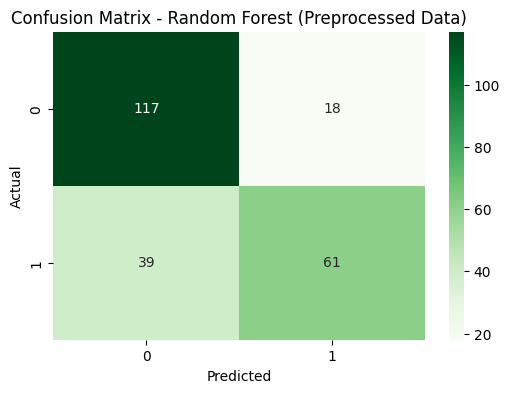


--- XGBoost Classifier (Preprocessed Data) ---
Laporan Klasifikasi untuk XGBoost (Preprocessed Data):
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       135
           1       0.79      0.67      0.72       100

    accuracy                           0.78       235
   macro avg       0.78      0.77      0.77       235
weighted avg       0.78      0.78      0.78       235

Akurasi untuk XGBoost (Preprocessed Data): 0.7829787234042553
AUC-ROC untuk XGBoost (Preprocessed Data): 0.8685185185185184


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:16:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


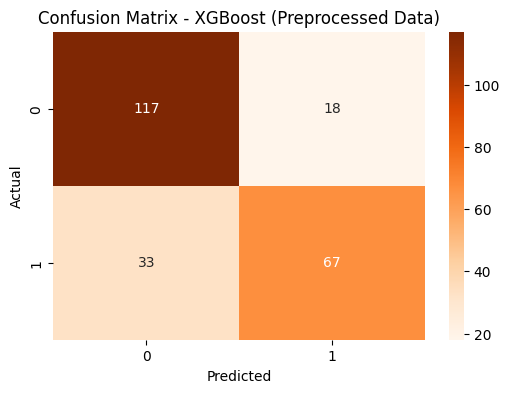

In [83]:
# Melatih kembali 3 model dengan data hasil preprocessing

# Import necessary library for AUC-ROC
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("Memulai pelatihan model dengan data hasil preprocessing...")

# 1. Decision Tree Classifier (dengan data preprocessed)
print("\n--- Decision Tree Classifier (Preprocessed Data) ---")
dt_model_preprocessed = DecisionTreeClassifier(random_state=42)
dt_model_preprocessed.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_dt_preprocessed = dt_model_preprocessed.predict(X_test_preprocessed)
y_proba_dt_preprocessed = dt_model_preprocessed.predict_proba(X_test_preprocessed)[:, 1]
print("Laporan Klasifikasi untuk Decision Tree (Preprocessed Data):")
print(classification_report(y_test_preprocessed, y_pred_dt_preprocessed))
print("Akurasi untuk Decision Tree (Preprocessed Data):", accuracy_score(y_test_preprocessed, y_pred_dt_preprocessed))
print("AUC-ROC untuk Decision Tree (Preprocessed Data):", roc_auc_score(y_test_preprocessed, y_proba_dt_preprocessed))

# Visualisasi Confusion Matrix untuk Decision Tree (Preprocessed Data)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_preprocessed, y_pred_dt_preprocessed), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree (Preprocessed Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. Random Forest Classifier (dengan data preprocessed)
print("\n--- Random Forest Classifier (Preprocessed Data) ---")
rf_model_preprocessed = RandomForestClassifier(random_state=42)
rf_model_preprocessed.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_rf_preprocessed = rf_model_preprocessed.predict(X_test_preprocessed)
y_proba_rf_preprocessed = rf_model_preprocessed.predict_proba(X_test_preprocessed)[:, 1]
print("Laporan Klasifikasi untuk Random Forest (Preprocessed Data):")
print(classification_report(y_test_preprocessed, y_pred_rf_preprocessed))
print("Akurasi untuk Random Forest (Preprocessed Data):", accuracy_score(y_test_preprocessed, y_pred_rf_preprocessed))
print("AUC-ROC untuk Random Forest (Preprocessed Data):", roc_auc_score(y_test_preprocessed, y_proba_rf_preprocessed))

# Visualisasi Confusion Matrix untuk Random Forest (Preprocessed Data)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_preprocessed, y_pred_rf_preprocessed), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest (Preprocessed Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. XGBoost Classifier (dengan data preprocessed)
print("\n--- XGBoost Classifier (Preprocessed Data) ---")
xgb_model_preprocessed = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model_preprocessed.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_xgb_preprocessed = xgb_model_preprocessed.predict(X_test_preprocessed)
y_proba_xgb_preprocessed = xgb_model_preprocessed.predict_proba(X_test_preprocessed)[:, 1]
print("Laporan Klasifikasi untuk XGBoost (Preprocessed Data):")
print(classification_report(y_test_preprocessed, y_pred_xgb_preprocessed))
print("Akurasi untuk XGBoost (Preprocessed Data):", accuracy_score(y_test_preprocessed, y_pred_xgb_preprocessed))
print("AUC-ROC untuk XGBoost (Preprocessed Data):", roc_auc_score(y_test_preprocessed, y_proba_xgb_preprocessed))

# Visualisasi Confusion Matrix untuk XGBoost (Preprocessed Data)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_preprocessed, y_pred_xgb_preprocessed), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost (Preprocessed Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Komparasi Model

In [91]:
print("\n--- Komparasi Akurasi, AUC-ROC, F1-Score, dan Recall Model Sebelum dan Sesudah Preprocessing ---")

# Metrics from models without preprocessing
# Decision Tree
report_dt_no_pre = classification_report(y_test, y_pred_dt, output_dict=True)
accuracy_dt_no_pre = accuracy_score(y_test, y_pred_dt)
auc_roc_dt_no_pre = roc_auc_score(y_test, y_proba_dt)
f1_dt_no_pre = report_dt_no_pre['weighted avg']['f1-score']
recall_dt_no_pre = report_dt_no_pre['weighted avg']['recall']

# Random Forest
report_rf_no_pre = classification_report(y_test, y_pred_rf, output_dict=True)
accuracy_rf_no_pre = accuracy_score(y_test, y_pred_rf)
auc_roc_rf_no_pre = roc_auc_score(y_test, y_proba_rf)
f1_rf_no_pre = report_rf_no_pre['weighted avg']['f1-score']
recall_rf_no_pre = report_rf_no_pre['weighted avg']['recall']

# XGBoost
report_xgb_no_pre = classification_report(y_test, y_pred_xgb, output_dict=True)
accuracy_xgb_no_pre = accuracy_score(y_test, y_pred_xgb)
auc_roc_xgb_no_pre = roc_auc_score(y_test, y_proba_xgb)
f1_xgb_no_pre = report_xgb_no_pre['weighted avg']['f1-score']
recall_xgb_no_pre = report_xgb_no_pre['weighted avg']['recall']

# Metrics from models with preprocessing
# Decision Tree
report_dt_pre = classification_report(y_test_preprocessed, y_pred_dt_preprocessed, output_dict=True)
accuracy_dt_pre = accuracy_score(y_test_preprocessed, y_pred_dt_preprocessed)
auc_roc_dt_pre = roc_auc_score(y_test_preprocessed, y_proba_dt_preprocessed)
f1_dt_pre = report_dt_pre['weighted avg']['f1-score']
recall_dt_pre = report_dt_pre['weighted avg']['recall']

# Random Forest
report_rf_pre = classification_report(y_test_preprocessed, y_pred_rf_preprocessed, output_dict=True)
accuracy_rf_pre = accuracy_score(y_test_preprocessed, y_pred_rf_preprocessed)
auc_roc_rf_pre = roc_auc_score(y_test_preprocessed, y_proba_rf_preprocessed)
f1_rf_pre = report_rf_pre['weighted avg']['f1-score']
recall_rf_pre = report_rf_pre['weighted avg']['recall']

# XGBoost
report_xgb_pre = classification_report(y_test_preprocessed, y_pred_xgb_preprocessed, output_dict=True)
accuracy_xgb_pre = accuracy_score(y_test_preprocessed, y_pred_xgb_preprocessed)
auc_roc_xgb_pre = roc_auc_score(y_test_preprocessed, y_proba_xgb_preprocessed)
f1_xgb_pre = report_xgb_pre['weighted avg']['f1-score']
recall_xgb_pre = report_xgb_pre['weighted avg']['recall']

# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Akurasi Tanpa Preprocessing': [accuracy_dt_no_pre, accuracy_rf_no_pre, accuracy_xgb_no_pre],
    'AUC-ROC Tanpa Preprocessing': [auc_roc_dt_no_pre, auc_roc_rf_no_pre, auc_roc_xgb_no_pre],
    'F1-Score (Weighted Avg) Tanpa Preprocessing': [f1_dt_no_pre, f1_rf_no_pre, f1_xgb_no_pre],
    'Recall (Weighted Avg) Tanpa Preprocessing': [recall_dt_no_pre, recall_rf_no_pre, recall_xgb_no_pre],
    'Akurasi Dengan Preprocessing': [accuracy_dt_pre, accuracy_rf_pre, accuracy_xgb_pre],
    'AUC-ROC Dengan Preprocessing': [auc_roc_dt_pre, auc_roc_rf_pre, auc_roc_xgb_pre],
    'F1-Score (Weighted Avg) Dengan Preprocessing': [f1_dt_pre, f1_rf_pre, f1_xgb_pre],
    'Recall (Weighted Avg) Dengan Preprocessing': [recall_dt_pre, recall_rf_pre, recall_xgb_pre]
})

# Round numerical columns for better readability
for col in comparison_df.columns:
    if comparison_df[col].dtype == 'float64':
        comparison_df[col] = comparison_df[col].round(4)

display(comparison_df)




--- Komparasi Akurasi, AUC-ROC, F1-Score, dan Recall Model Sebelum dan Sesudah Preprocessing ---


,Model,Akurasi Tanpa Preprocessing,AUC-ROC Tanpa Preprocessing,F1-Score (Weighted Avg) Tanpa Preprocessing,Recall (Weighted Avg) Tanpa Preprocessing,Akurasi Dengan Preprocessing,AUC-ROC Dengan Preprocessing,F1-Score (Weighted Avg) Dengan Preprocessing,Recall (Weighted Avg) Dengan Preprocessing
0,Decision Tree,0.7106,0.6989,0.7088,0.7106,0.7149,0.6987,0.7108,0.7149
1,Random Forest,0.7617,0.8536,0.7586,0.7617,0.7574,0.8584,0.7520,0.7574
2,XGBoost,0.8128,0.8914,0.8103,0.8128,0.7830,0.8685,0.7799,0.7830


In [74]:
# 1. Import the SMOTE class
from imblearn.over_sampling import SMOTE

# 2. Inisialisasi objek SMOTE
smote = SMOTE(random_state=42)

# 3. Aplikasikan fit_resample pada X_train_preprocessed dan y_train_preprocessed
print("Menerapkan SMOTE pada data pelatihan...")
X_resampled, y_resampled = smote.fit_resample(X_train_preprocessed, y_train_preprocessed)

# 4. Cetak shape dari X_resampled dan y_resampled
print(f"Shape dari X_resampled setelah SMOTE: {X_resampled.shape}")
print(f"Shape dari y_resampled setelah SMOTE: {y_resampled.shape}")

# 5. Cetak distribusi kelas dari y_resampled
print("\nDistribusi kelas dari y_resampled setelah SMOTE:")
print(y_resampled.value_counts())

Menerapkan SMOTE pada data pelatihan...
Shape dari X_resampled setelah SMOTE: (1308, 33)
Shape dari y_resampled setelah SMOTE: (1308,)

Distribusi kelas dari y_resampled setelah SMOTE:
Attrition
1    654
0    654
Name: count, dtype: int64



Skor Fitur setelah seleksi dengan SelectKBest (top 15):


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 3 23 25 29 30] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Feature,Score,P_Value
0,JobTitle,342.089800,5.086660e-68
1,Job_Opportunities,169.999813,1.283007e-36
2,Department,123.916056,1.461017e-27
3,Sector,106.621399,4.416311e-24
4,Rewards_Wages_Satisfaction,86.420941,5.906204e-20
5,Job_Stability,85.693639,8.339850e-20
6,Training_programs_During_last_three_years,81.227736,6.971532e-19
7,Get_Deserved_Promotion,77.225128,4.708239e-18
8,Job_Satisfaction,73.703100,2.542202e-17
9,Job_Support,67.457938,5.123090e-16


/tmp/ipython-input-2077060973.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=feature_scores.head(k_features), palette='viridis')


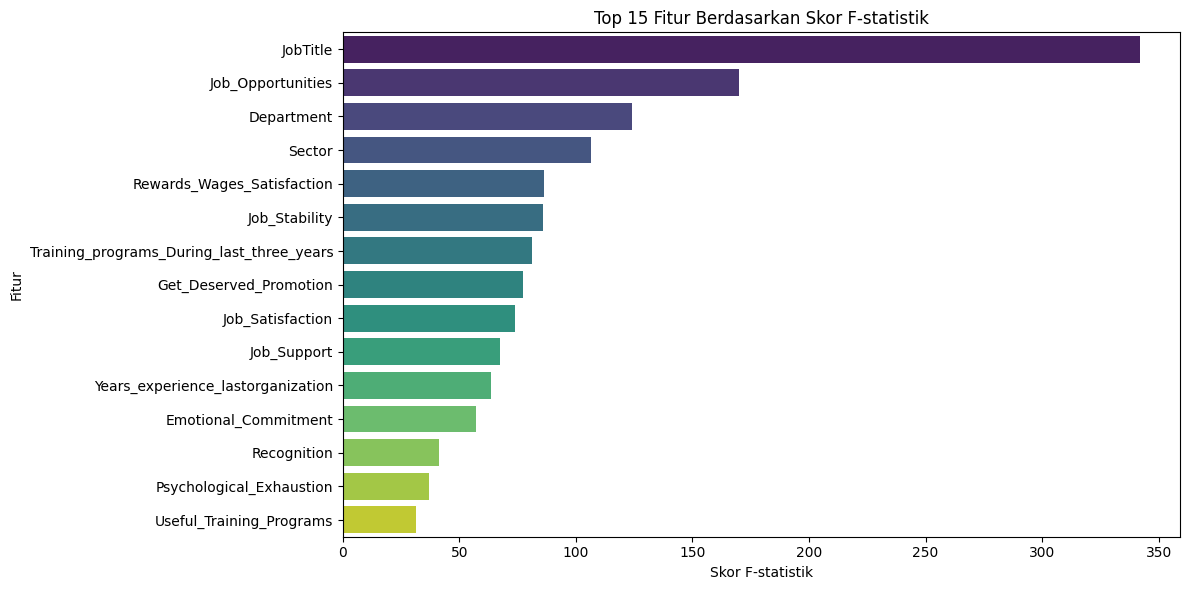


Fitur yang terpilih: ['JobTitle', 'Job_Opportunities', 'Department', 'Sector', 'Rewards_Wages_Satisfaction', 'Job_Stability', 'Training_programs_During_last_three_years', 'Get_Deserved_Promotion', 'Job_Satisfaction', 'Job_Support', 'Years_experience_lastorganization', 'Emotional_Commitment', 'Recognition', 'Psychological_Exhaustion', 'Useful_Training_Programs']

Shape X_resampled_selected setelah seleksi fitur: (1308, 15)
Shape X_test_selected setelah seleksi fitur: (235, 15)


In [75]:
# 1. Import SelectKBest dan f_classif
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Aplikasikan SelectKBest pada X_resampled dan y_resampled
# Memilih 15 fitur terbaik (k=15 bisa disesuaikan)
k_features = 15
selector = SelectKBest(score_func=f_classif, k=k_features)
selector.fit(X_resampled, y_resampled)

# 3. Tampilkan skor fitur dalam bentuk DataFrame yang terurut
feature_scores = pd.DataFrame({
    'Feature': X_resampled.columns,
    'Score': selector.scores_,
    'P_Value': selector.pvalues_
})
feature_scores = feature_scores.sort_values(by='Score', ascending=False).reset_index(drop=True)

print(f"\nSkor Fitur setelah seleksi dengan SelectKBest (top {k_features}):")
display(feature_scores.head(k_features))

# Visualisasi skor fitur
plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(k_features), palette='viridis')
plt.title(f'Top {k_features} Fitur Berdasarkan Skor F-statistik')
plt.xlabel('Skor F-statistik')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

# 4. Pilih fitur-fitur terbaik
selected_features = feature_scores.head(k_features)['Feature'].tolist()
print(f"\nFitur yang terpilih: {selected_features}")

# 5. Transformasikan X_resampled dan X_test_preprocessed
X_resampled_selected = X_resampled[selected_features]
X_test_selected = X_test_preprocessed[selected_features]

# 6. Cetak bentuk DataFrame baru
print(f"\nShape X_resampled_selected setelah seleksi fitur: {X_resampled_selected.shape}")
print(f"Shape X_test_selected setelah seleksi fitur: {X_test_selected.shape}")

## Hyperparameter_Tuning_DecisionTree

In [76]:
from sklearn.model_selection import GridSearchCV

# Definisikan grid parameter untuk DecisionTreeClassifier
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inisialisasi DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV ke data pelatihan yang sudah diresampled dan diseleksi fiturnya
print("Memulai GridSearchCV untuk Decision Tree...")
grid_search.fit(X_resampled_selected, y_resampled)

# Cetak parameter terbaik dan skor terbaik
print("\nParameter Terbaik untuk Decision Tree:", grid_search.best_params_)
print("Skor Terbaik untuk Decision Tree:", grid_search.best_score_)


Memulai GridSearchCV untuk Decision Tree...

Parameter Terbaik untuk Decision Tree: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Skor Terbaik untuk Decision Tree: 0.7630399812816239


## Hyperparameter_Tuning_RandomForest

In [78]:
from sklearn.ensemble import RandomForestClassifier

# Definisikan grid parameter untuk RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Inisialisasi RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Inisialisasi GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV ke data pelatihan yang sudah diresampled dan diseleksi fiturnya
print("Memulai GridSearchCV untuk Random Forest...")
grid_search_rf.fit(X_resampled_selected, y_resampled)

# Cetak parameter terbaik dan skor terbaik
print("\nParameter Terbaik untuk Random Forest:", grid_search_rf.best_params_)
print("Skor Terbaik untuk Random Forest:", grid_search_rf.best_score_)

Memulai GridSearchCV untuk Random Forest...

Parameter Terbaik untuk Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Skor Terbaik untuk Random Forest: 0.8119914597408675


## Hyperparameter_Tuning_XGBoost


In [79]:
import xgboost as xgb

# Definisikan grid parameter untuk XGBClassifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# Inisialisasi XGBClassifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Inisialisasi GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV ke data pelatihan yang sudah diresampled dan diseleksi fiturnya
print("Memulai GridSearchCV untuk XGBoost...")
grid_search_xgb.fit(X_resampled_selected, y_resampled)

# Cetak parameter terbaik dan skor terbaik
print("\nParameter Terbaik untuk XGBoost:", grid_search_xgb.best_params_)
print("Skor Terbaik untuk XGBoost:", grid_search_xgb.best_score_)

Memulai GridSearchCV untuk XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:13:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Parameter Terbaik untuk XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.9}
Skor Terbaik untuk XGBoost: 0.8058699657804687


## Melatih Model setelah Tunning

Memulai pelatihan model dengan data hasil preprocessing, seleksi fitur, dan hyperparameter tuning...

--- Decision Tree Classifier (Optimized) ---
Laporan Klasifikasi untuk Decision Tree (Optimized):
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       135
           1       0.66      0.58      0.62       100

    accuracy                           0.69       235
   macro avg       0.69      0.68      0.68       235
weighted avg       0.69      0.69      0.69       235

Akurasi untuk Decision Tree (Optimized): 0.6936170212765957
AUC-ROC untuk Decision Tree (Optimized): 0.7476666666666667


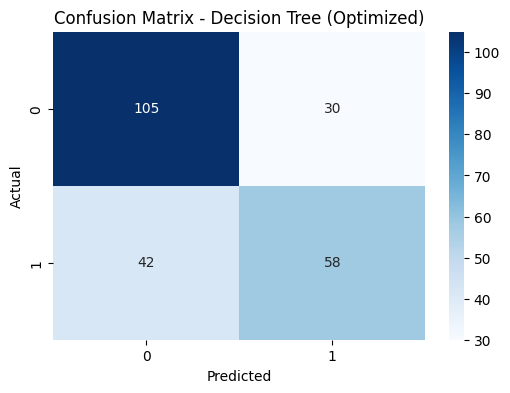


--- Random Forest Classifier (Optimized) ---
Laporan Klasifikasi untuk Random Forest (Optimized):
              precision    recall  f1-score   support

           0       0.74      0.77      0.76       135
           1       0.67      0.64      0.66       100

    accuracy                           0.71       235
   macro avg       0.71      0.71      0.71       235
weighted avg       0.71      0.71      0.71       235

Akurasi untuk Random Forest (Optimized): 0.7148936170212766
AUC-ROC untuk Random Forest (Optimized): 0.7997037037037037


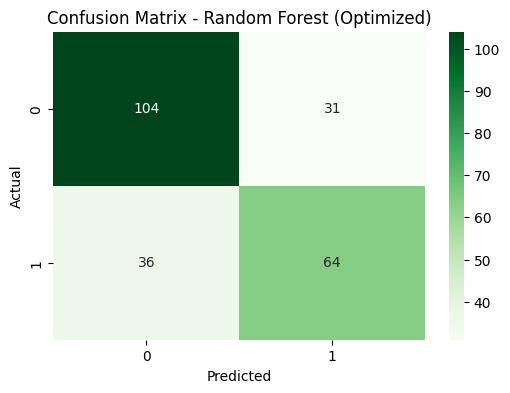


--- XGBoost Classifier (Optimized) ---
Laporan Klasifikasi untuk XGBoost (Optimized):
              precision    recall  f1-score   support

           0       0.70      0.78      0.74       135
           1       0.65      0.55      0.59       100

    accuracy                           0.68       235
   macro avg       0.67      0.66      0.67       235
weighted avg       0.68      0.68      0.68       235

Akurasi untuk XGBoost (Optimized): 0.6808510638297872
AUC-ROC untuk XGBoost (Optimized): 0.7717037037037037


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:19:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


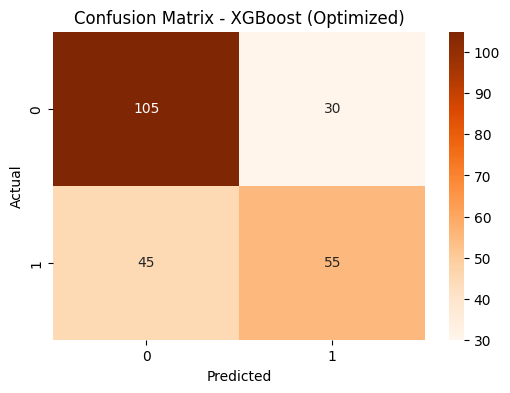

In [84]:
# Re_evaluate_Optimized_Models: Melatih kembali dan mengevaluasi ketiga model (Decision Tree, Random Forest, XGBoost) menggunakan data yang telah di-resampling, dengan fitur yang diseleksi, dan hyperparameter yang telah di-tuning.

# Import necessary library for AUC-ROC
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("Memulai pelatihan model dengan data hasil preprocessing, seleksi fitur, dan hyperparameter tuning...")

# 1. Decision Tree Classifier (Optimized Data & Hyperparameters)
print("\n--- Decision Tree Classifier (Optimized) ---")
dt_model_optimized = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
dt_model_optimized.fit(X_resampled_selected, y_resampled)
y_pred_dt_optimized = dt_model_optimized.predict(X_test_selected)
y_proba_dt_optimized = dt_model_optimized.predict_proba(X_test_selected)[:, 1]
print("Laporan Klasifikasi untuk Decision Tree (Optimized):")
print(classification_report(y_test_preprocessed, y_pred_dt_optimized))
print("Akurasi untuk Decision Tree (Optimized):", accuracy_score(y_test_preprocessed, y_pred_dt_optimized))
print("AUC-ROC untuk Decision Tree (Optimized):", roc_auc_score(y_test_preprocessed, y_proba_dt_optimized))

# Visualisasi Confusion Matrix untuk Decision Tree (Optimized)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_preprocessed, y_pred_dt_optimized), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree (Optimized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. Random Forest Classifier (Optimized Data & Hyperparameters)
print("\n--- Random Forest Classifier (Optimized) ---")
rf_model_optimized = RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)
rf_model_optimized.fit(X_resampled_selected, y_resampled)
y_pred_rf_optimized = rf_model_optimized.predict(X_test_selected)
y_proba_rf_optimized = rf_model_optimized.predict_proba(X_test_selected)[:, 1]
print("Laporan Klasifikasi untuk Random Forest (Optimized):")
print(classification_report(y_test_preprocessed, y_pred_rf_optimized))
print("Akurasi untuk Random Forest (Optimized):", accuracy_score(y_test_preprocessed, y_pred_rf_optimized))
print("AUC-ROC untuk Random Forest (Optimized):", roc_auc_score(y_test_preprocessed, y_proba_rf_optimized))

# Visualisasi Confusion Matrix untuk Random Forest (Optimized)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_preprocessed, y_pred_rf_optimized), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest (Optimized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. XGBoost Classifier (Optimized Data & Hyperparameters)
print("\n--- XGBoost Classifier (Optimized) ---")
xgb_model_optimized = xgb.XGBClassifier(**grid_search_xgb.best_params_, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model_optimized.fit(X_resampled_selected, y_resampled)
y_pred_xgb_optimized = xgb_model_optimized.predict(X_test_selected)
y_proba_xgb_optimized = xgb_model_optimized.predict_proba(X_test_selected)[:, 1]
print("Laporan Klasifikasi untuk XGBoost (Optimized):")
print(classification_report(y_test_preprocessed, y_pred_xgb_optimized))
print("Akurasi untuk XGBoost (Optimized):", accuracy_score(y_test_preprocessed, y_pred_xgb_optimized))
print("AUC-ROC untuk XGBoost (Optimized):", roc_auc_score(y_test_preprocessed, y_proba_xgb_optimized))

# Visualisasi Confusion Matrix untuk XGBoost (Optimized)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_preprocessed, y_pred_xgb_optimized), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost (Optimized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Komparasi Akurasi, AUC-ROC, F1-Score, dan Recall Model Sebelum dan Sesudah Preprocessing & Optimasi ---


,Model,Akurasi Tanpa Preprocessing,AUC-ROC Tanpa Preprocessing,F1-Score (Weighted Avg) Tanpa Preprocessing,Recall (Weighted Avg) Tanpa Preprocessing,Akurasi Dengan Preprocessing,AUC-ROC Dengan Preprocessing,F1-Score (Weighted Avg) Dengan Preprocessing,Recall (Weighted Avg) Dengan Preprocessing,Akurasi Setelah Optimasi,AUC-ROC Setelah Optimasi,F1-Score (Weighted Avg) Setelah Optimasi,Recall (Weighted Avg) Setelah Optimasi
0,Decision Tree,0.7106,0.6989,0.7088,0.7106,0.7149,0.6987,0.7108,0.7149,0.6936,0.7477,0.6904,0.6936
1,Random Forest,0.7617,0.8536,0.7586,0.7617,0.7574,0.8584,0.7520,0.7574,0.7149,0.7997,0.7138,0.7149
2,XGBoost,0.8128,0.8914,0.8103,0.8128,0.7830,0.8685,0.7799,0.7830,0.6809,0.7717,0.6763,0.6809



Dari tabel di atas, kita bisa melihat bagaimana setiap tahap optimasi (preprocessing, resampling, seleksi fitur, dan hyperparameter tuning) mempengaruhi kinerja model berdasarkan metrik Akurasi, AUC-ROC, F1-Score, dan Recall.


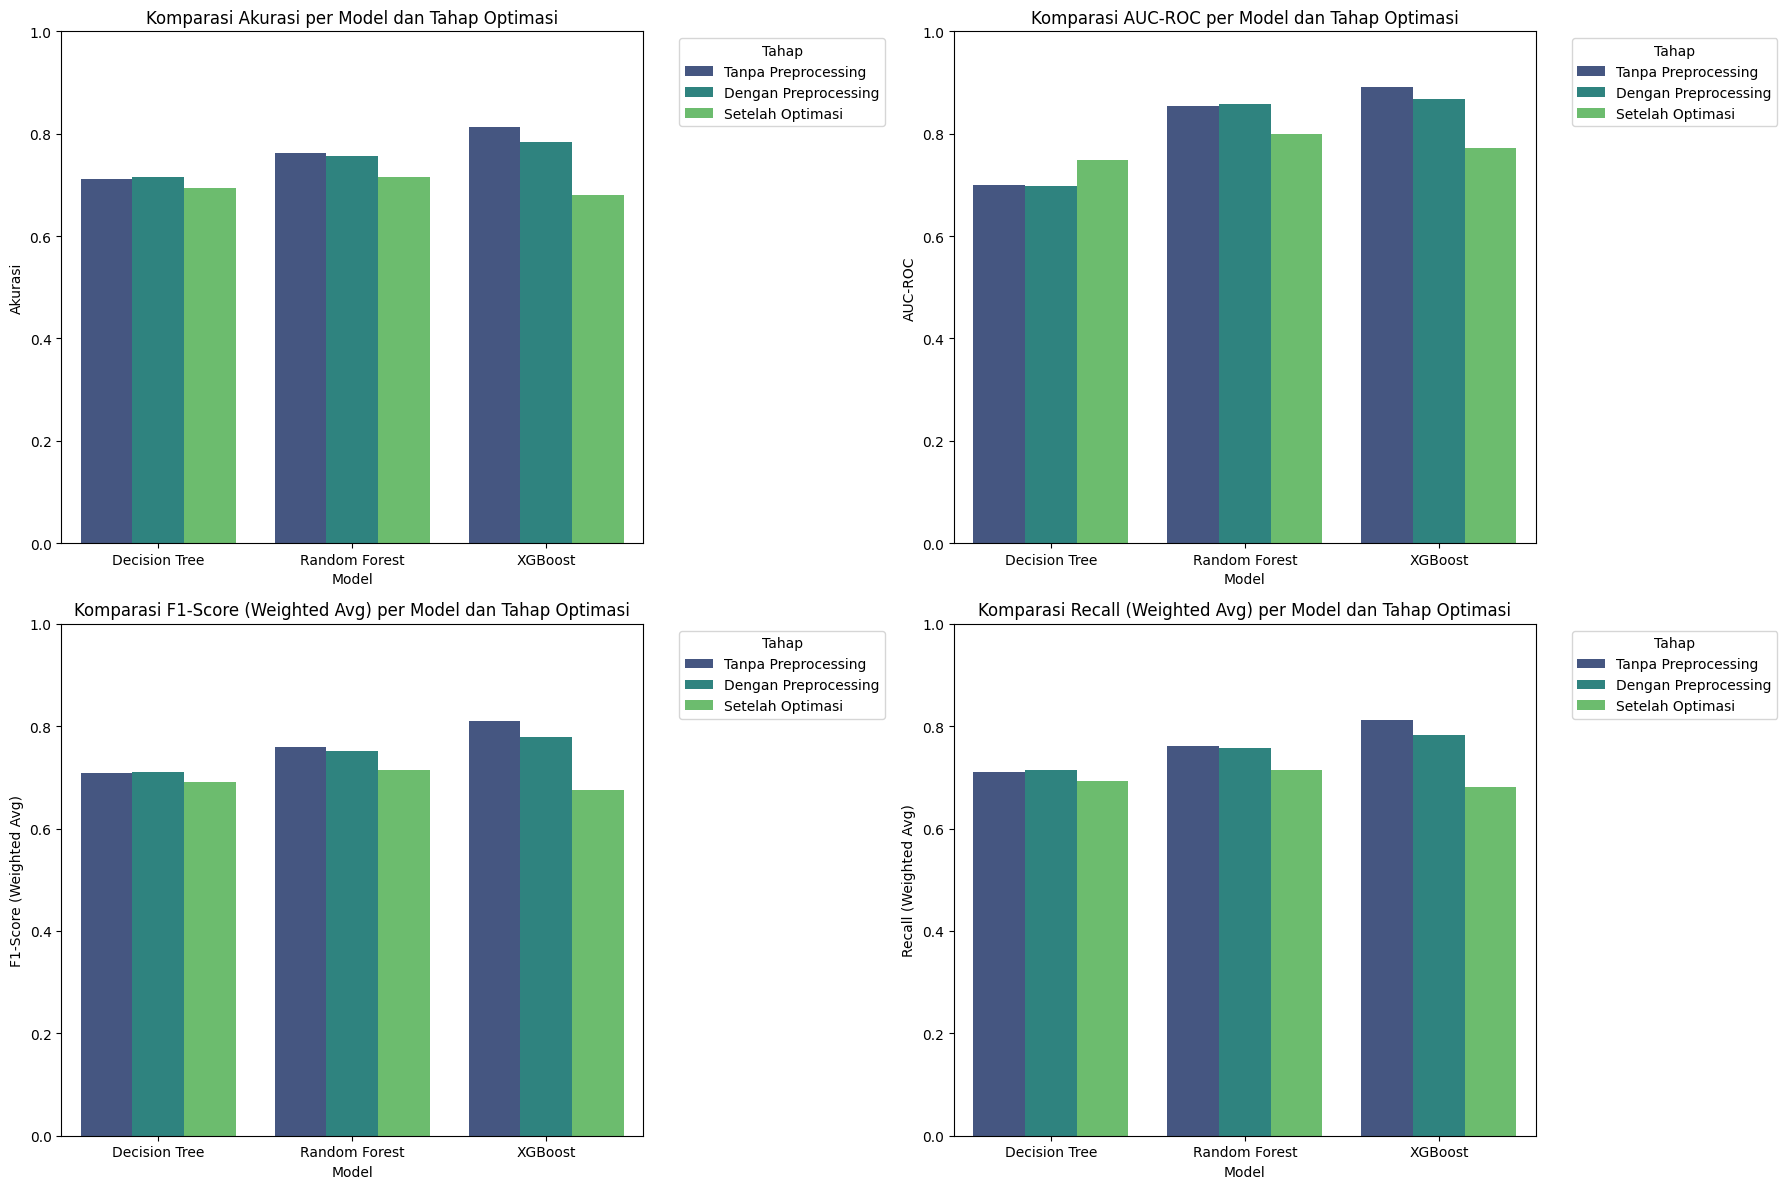

In [88]:
print("\n--- Komparasi Akurasi, AUC-ROC, F1-Score, dan Recall Model Sebelum dan Sesudah Preprocessing & Optimasi ---")

# Metrics from models without preprocessing
# Decision Tree
report_dt_no_pre = classification_report(y_test, y_pred_dt, output_dict=True)
accuracy_dt_no_pre = accuracy_score(y_test, y_pred_dt)
auc_roc_dt_no_pre = roc_auc_score(y_test, y_proba_dt)
f1_dt_no_pre = report_dt_no_pre['weighted avg']['f1-score']
recall_dt_no_pre = report_dt_no_pre['weighted avg']['recall']

# Random Forest
report_rf_no_pre = classification_report(y_test, y_pred_rf, output_dict=True)
accuracy_rf_no_pre = accuracy_score(y_test, y_pred_rf)
auc_roc_rf_no_pre = roc_auc_score(y_test, y_proba_rf)
f1_rf_no_pre = report_rf_no_pre['weighted avg']['f1-score']
recall_rf_no_pre = report_rf_no_pre['weighted avg']['recall']

# XGBoost
report_xgb_no_pre = classification_report(y_test, y_pred_xgb, output_dict=True)
accuracy_xgb_no_pre = accuracy_score(y_test, y_pred_xgb)
auc_roc_xgb_no_pre = roc_auc_score(y_test, y_proba_xgb)
f1_xgb_no_pre = report_xgb_no_pre['weighted avg']['f1-score']
recall_xgb_no_pre = report_xgb_no_pre['weighted avg']['recall']


# Metrics from models with preprocessing (before tuning and feature selection)
# Decision Tree
report_dt_pre = classification_report(y_test_preprocessed, y_pred_dt_preprocessed, output_dict=True)
accuracy_dt_pre = accuracy_score(y_test_preprocessed, y_pred_dt_preprocessed)
auc_roc_dt_pre = roc_auc_score(y_test_preprocessed, y_proba_dt_preprocessed)
f1_dt_pre = report_dt_pre['weighted avg']['f1-score']
recall_dt_pre = report_dt_pre['weighted avg']['recall']

# Random Forest
report_rf_pre = classification_report(y_test_preprocessed, y_pred_rf_preprocessed, output_dict=True)
accuracy_rf_pre = accuracy_score(y_test_preprocessed, y_pred_rf_preprocessed)
auc_roc_rf_pre = roc_auc_score(y_test_preprocessed, y_proba_rf_preprocessed)
f1_rf_pre = report_rf_pre['weighted avg']['f1-score']
recall_rf_pre = report_rf_pre['weighted avg']['recall']

# XGBoost
report_xgb_pre = classification_report(y_test_preprocessed, y_pred_xgb_preprocessed, output_dict=True)
accuracy_xgb_pre = accuracy_score(y_test_preprocessed, y_pred_xgb_preprocessed)
auc_roc_xgb_pre = roc_auc_score(y_test_preprocessed, y_proba_xgb_preprocessed)
f1_xgb_pre = report_xgb_pre['weighted avg']['f1-score']
recall_xgb_pre = report_xgb_pre['weighted avg']['recall']


# Metrics from optimized models (resampling, feature selection, hyperparameter tuning)
# Decision Tree Optimized
report_dt_optimized = classification_report(y_test_preprocessed, y_pred_dt_optimized, output_dict=True)
accuracy_dt_optimized = accuracy_score(y_test_preprocessed, y_pred_dt_optimized)
auc_roc_dt_optimized = roc_auc_score(y_test_preprocessed, y_proba_dt_optimized)
f1_dt_optimized = report_dt_optimized['weighted avg']['f1-score']
recall_dt_optimized = report_dt_optimized['weighted avg']['recall']

# Random Forest Optimized
report_rf_optimized = classification_report(y_test_preprocessed, y_pred_rf_optimized, output_dict=True)
accuracy_rf_optimized = accuracy_score(y_test_preprocessed, y_pred_rf_optimized)
auc_roc_rf_optimized = roc_auc_score(y_test_preprocessed, y_proba_rf_optimized)
f1_rf_optimized = report_rf_optimized['weighted avg']['f1-score']
recall_rf_optimized = report_rf_optimized['weighted avg']['recall']

# XGBoost Optimized
report_xgb_optimized = classification_report(y_test_preprocessed, y_pred_xgb_optimized, output_dict=True)
accuracy_xgb_optimized = accuracy_score(y_test_preprocessed, y_pred_xgb_optimized)
auc_roc_xgb_optimized = roc_auc_score(y_test_preprocessed, y_proba_xgb_optimized)
f1_xgb_optimized = report_xgb_optimized['weighted avg']['f1-score']
recall_xgb_optimized = report_xgb_optimized['weighted avg']['recall']


# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Akurasi Tanpa Preprocessing': [accuracy_dt_no_pre, accuracy_rf_no_pre, accuracy_xgb_no_pre],
    'AUC-ROC Tanpa Preprocessing': [auc_roc_dt_no_pre, auc_roc_rf_no_pre, auc_roc_xgb_no_pre],
    'F1-Score (Weighted Avg) Tanpa Preprocessing': [f1_dt_no_pre, f1_rf_no_pre, f1_xgb_no_pre],
    'Recall (Weighted Avg) Tanpa Preprocessing': [recall_dt_no_pre, recall_rf_no_pre, recall_xgb_no_pre],

    'Akurasi Dengan Preprocessing': [accuracy_dt_pre, accuracy_rf_pre, accuracy_xgb_pre],
    'AUC-ROC Dengan Preprocessing': [auc_roc_dt_pre, auc_roc_rf_pre, auc_roc_xgb_pre],
    'F1-Score (Weighted Avg) Dengan Preprocessing': [f1_dt_pre, f1_rf_pre, f1_xgb_pre],
    'Recall (Weighted Avg) Dengan Preprocessing': [recall_dt_pre, recall_rf_pre, recall_xgb_pre],

    'Akurasi Setelah Optimasi': [accuracy_dt_optimized, accuracy_rf_optimized, accuracy_xgb_optimized],
    'AUC-ROC Setelah Optimasi': [auc_roc_dt_optimized, auc_roc_rf_optimized, auc_roc_xgb_optimized],
    'F1-Score (Weighted Avg) Setelah Optimasi': [f1_dt_optimized, f1_rf_optimized, f1_xgb_optimized],
    'Recall (Weighted Avg) Setelah Optimasi': [recall_dt_optimized, recall_rf_optimized, recall_xgb_optimized]
})

# Round numerical columns for better readability
for col in comparison_df.columns:
    if comparison_df[col].dtype == 'float64':
        comparison_df[col] = comparison_df[col].round(4)

display(comparison_df)

print("\nDari tabel di atas, kita bisa melihat bagaimana setiap tahap optimasi (preprocessing, resampling, seleksi fitur, dan hyperparameter tuning) mempengaruhi kinerja model berdasarkan metrik Akurasi, AUC-ROC, F1-Score, dan Recall.")

# Visualisasi Komparasi Metrik

# Melt the DataFrame for easier plotting with seaborn
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric_Stage', value_name='Score')

# Extract Metric and Stage information
comparison_melted[['Metric', 'Stage']] = comparison_melted['Metric_Stage'].str.split(' Dengan | Tanpa | Setelah ', expand=True)
comparison_melted['Stage'] = comparison_melted['Metric_Stage'].apply(lambda x: 'Tanpa Preprocessing' if 'Tanpa Preprocessing' in x else ('Dengan Preprocessing' if 'Dengan Preprocessing' in x else 'Setelah Optimasi'))
comparison_melted['Metric'] = comparison_melted['Metric_Stage'].apply(lambda x: x.split(' Tanpa ')[0] if 'Tanpa' in x else (x.split(' Dengan ')[0] if 'Dengan' in x else x.split(' Setelah ')[0]))

# Filter out irrelevant Metric_Stage names from original columns if any remain after split
comparison_melted = comparison_melted[~comparison_melted['Metric_Stage'].isin(['Model'])]

metrics_to_plot = ['Akurasi', 'AUC-ROC', 'F1-Score (Weighted Avg)', 'Recall (Weighted Avg)']

plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.barplot(x='Model', y='Score', hue='Stage', data=comparison_melted[comparison_melted['Metric'] == metric], palette='viridis')
    plt.title(f'Komparasi {metric} per Model dan Tahap Optimasi')
    plt.ylabel(metric)
    plt.ylim(0, 1) # Metrics are usually between 0 and 1
    plt.xticks(rotation=0)
    plt.legend(title='Tahap', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()